# 🧠 Splotowe sieci neuronowe (CNN) - cz.3

## Transfer Learning w PyTorch

## Wprowadzenie

Dzisiejsze laboratorium dotyczy zagadnienia **transfer learningu**.

Transfer learning polega na wykorzystaniu modeli wytrenowanych wcześniej
(np. na ogromnym zbiorze ImageNet) i dostosowaniu ich do nowego problemu.

Dzięki temu:
- potrzebujemy mniej danych,
- trening jest szybszy,
- modele osiągają lepsze wyniki.

Najczęściej wykorzystujemy modele pretrenowane na zbiorze:
- **ImageNet**
- ponad 1 milion obrazów
- 1000 klas obiektów

*Pamiętaj o włączeniu GPU

In [19]:
import time
import pathlib
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import models, transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

import urllib.request
import zipfile
import os

from collections import Counter

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [20]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda:0
GPU: NVIDIA GeForce RTX 3070 Ti


## 🚀 Pretraining i Fine-tuning

Proces transfer learningu składa się zwykle z dwóch etapów:

### 1. **Pretraining**
Model jest trenowany na bardzo dużym zbiorze danych.

Przykład:
- ResNet trenowany na ImageNet.

### 2. **Fine-tuning**
Model zostaje dostosowany do nowego problemu.

Przykład:
- klasyfikacja pszczół i mrówek.

## Dlaczego transfer learning działa?

Pierwsze warstwy CNN uczą się uniwersalnych cech obrazów:
- krawędzi,
- tekstur,
- prostych kształtów.

Dopiero późniejsze warstwy uczą się bardziej abstrakcyjnych reprezentacji.

Dlatego wiedzę zdobytą na ImageNet można przenieść
do wielu innych problemów komputerowego rozpoznawania obrazów.

## Przykładowe modele dostępne w torchvision

Pakiet `torchvision.models` zawiera wiele gotowych architektur:
- ResNet,
- EfficientNet,
- VGG,
- DenseNet,
- MobileNet,
- Vision Transformer.

Wiele z nich posiada gotowe pretrenowane wagi.

In [21]:
dir(models)

['AlexNet',
 'AlexNet_Weights',
 'ConvNeXt',
 'ConvNeXt_Base_Weights',
 'ConvNeXt_Large_Weights',
 'ConvNeXt_Small_Weights',
 'ConvNeXt_Tiny_Weights',
 'DenseNet',
 'DenseNet121_Weights',
 'DenseNet161_Weights',
 'DenseNet169_Weights',
 'DenseNet201_Weights',
 'EfficientNet',
 'EfficientNet_B0_Weights',
 'EfficientNet_B1_Weights',
 'EfficientNet_B2_Weights',
 'EfficientNet_B3_Weights',
 'EfficientNet_B4_Weights',
 'EfficientNet_B5_Weights',
 'EfficientNet_B6_Weights',
 'EfficientNet_B7_Weights',
 'EfficientNet_V2_L_Weights',
 'EfficientNet_V2_M_Weights',
 'EfficientNet_V2_S_Weights',
 'GoogLeNet',
 'GoogLeNetOutputs',
 'GoogLeNet_Weights',
 'Inception3',
 'InceptionOutputs',
 'Inception_V3_Weights',
 'MNASNet',
 'MNASNet0_5_Weights',
 'MNASNet0_75_Weights',
 'MNASNet1_0_Weights',
 'MNASNet1_3_Weights',
 'MaxVit',
 'MaxVit_T_Weights',
 'MobileNetV2',
 'MobileNetV3',
 'MobileNet_V2_Weights',
 'MobileNet_V3_Large_Weights',
 'MobileNet_V3_Small_Weights',
 'RegNet',
 'RegNet_X_16GF_Weights'

In [22]:
weights = models.ResNet18_Weights.DEFAULT

model_example = models.resnet18(weights=weights)
print(model_example)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Patryk/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 112MB/s] 

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## 🐝 vs 🐜 Dataset Hymenoptera

W laboratorium wykorzystamy klasyczny zbiór:
- pszczoły (*bees*)
- mrówki (*ants*)

Jest to problem:
- klasyfikacji binarnej,
- z niewielką liczbą obrazów,
- idealny do transfer learningu.

### Pobieranie danych

Zbiór Hymenoptera zostanie automatycznie pobrany
i rozpakowany w środowisku Google Colab z użyciem poniższych komórek.

In [23]:
DATA_URL = "https://download.pytorch.org/tutorial/hymenoptera_data.zip"

ZIP_PATH = "hymenoptera_data.zip"

DATA_PATH = pathlib.Path("hymenoptera_data")

In [24]:
# pobieranie danych
if not os.path.exists(ZIP_PATH):

    print("Downloading dataset...")

    urllib.request.urlretrieve(
        DATA_URL,
        ZIP_PATH
    )

    print("Download complete.")

# rozpakowanie danych
if not DATA_PATH.exists():

    print("Extracting dataset...")

    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(".")

    print("Extraction complete.")

### Sprawdzenie i wizualizacja danych

#### Dataset `ImageFolder`

PyTorch udostępnia gotową klasę `ImageFolder`,
która automatycznie wczytuje obrazy z katalogów.

Struktura katalogów powinna wyglądać następująco:

```text
dataset/
    train/
        ants/
            img1.jpg
            img2.jpg
        bees/
            img3.jpg
            img4.jpg
```
Domyślnie `ImageFolder` wczytuje obrazy jako obiekty:
- `PIL.Image`

#### ✅ Zadanie 1
Użyj klasy `ImageFolder` żeby wczytać dane:
* sprawdź liczność danych w zbiorze treningowy i walidacyjnym,
* sprawdź rozkład klas w zbiorze,
* zwizualizuj kilka przykładów.

### Transformacje obrazów

Modele pretrenowane oczekują obrazów:
- o odpowiednim rozmiarze,
- odpowiednio znormalizowanych.

Dla modeli trenowanych na ImageNet standardowo:
- resize do `256 px`,
- center crop `224x224`,
- normalizacja kanałów RGB.

#### Normalizacja i augmentacja danych

##### **Normalizacja danych**

Dla ImageNet używa się standardowo:

Mean:
- `[0.485, 0.456, 0.406]`

Std:
- `[0.229, 0.224, 0.225]`

##### **Augmentacja danych**
Augmentacja danych (data augmentation) polega na tworzeniu różnych wersji tego samego obrazu poprzez losowe transformacje podczas **treningu**, np.:
- obrót,
- odbicie,
- przycięcie,
- zmianę jasności lub kontrastu.

Pozwala:
- zwiększyć różnorodność danych,
- ograniczyć overfitting,
- poprawić generalizację modelu.

###### **Dlaczego rozmiar datasetu się nie zmienia?**

Transformacje działają **dynamicznie podczas ładowania obrazu** (on-the-fly), dlatego:
- liczba elementów w datasetcie (`len(dataset)`) pozostaje taka sama,
- oryginalne pliki obrazów nie są modyfikowane,
- przy każdym odczycie obrazu mogą zostać zastosowane inne losowe transformacje.

In [25]:
# Wczytanie surowych danych (bez transformacji)
raw_train = ImageFolder(root=DATA_PATH / "train")
raw_val   = ImageFolder(root=DATA_PATH / "val")

print("Klasy:", raw_train.classes)
print(f"Liczba obrazów treningowych: {len(raw_train)}")
print(f"Liczba obrazów walidacyjnych: {len(raw_val)}")

# Rozkład klas
train_counter = Counter([label for _, label in raw_train.samples])
val_counter   = Counter([label for _, label in raw_val.samples])

print("\nRozkład klas – TRAIN:")
for cls, idx in raw_train.class_to_idx.items():
    print(f"  {cls}: {train_counter[idx]} obrazów")

print("\nRozkład klas – VAL:")
for cls, idx in raw_val.class_to_idx.items():
    print(f"  {cls}: {val_counter[idx]} obrazów")

Klasy: ['ants', 'bees']
Liczba obrazów treningowych: 244
Liczba obrazów walidacyjnych: 153

Rozkład klas – TRAIN:
  ants: 123 obrazów
  bees: 121 obrazów

Rozkład klas – VAL:
  ants: 70 obrazów
  bees: 83 obrazów


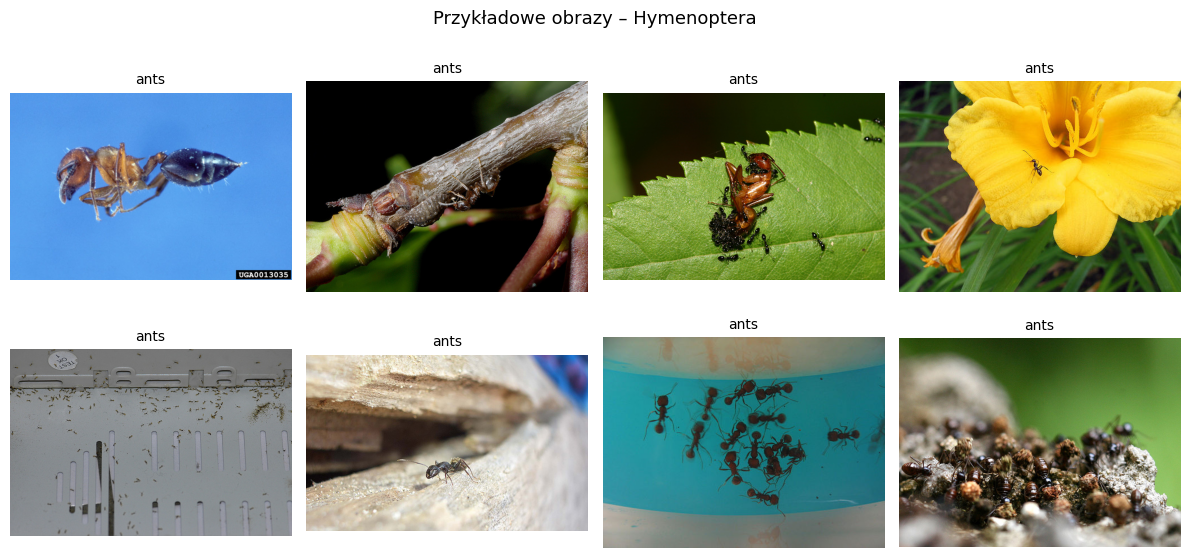

In [26]:
# Wizualizacja przykładów
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flatten()):
    img, label = raw_train[i * 15]
    ax.imshow(img)
    ax.set_title(raw_train.classes[label], fontsize=10)
    ax.axis("off")

plt.suptitle("Przykładowe obrazy – Hymenoptera", fontsize=13)
plt.tight_layout()
plt.show()

In [27]:
IMAGENET_MEANS = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

IMAGENET_IMG_SIZE = 224

In [28]:
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMAGENET_IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEANS, IMAGENET_STD)
])

val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGENET_IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEANS, IMAGENET_STD)
])

##### ✅ Zadanie 2
- Przeanalizuj podane wyżej transformacje - poszukaj w dokumentacji i opisz co one robią, jakie parametry przyjmują.
- Użyj podanych wyżej transformacji przy wczytywaniu obrazów za pomocą ImageFolder.
- Zaimplementuj DataLoadery dla danych treningowych i walidaycjnych.

### Transformacje obrazów

#### ✅ Zadanie 2 – Analiza transformacji i implementacja DataLoaderów

Opis transformacji (na podstawie dokumentacji PyTorch):

| Transformacja | Co robi | Parametry |
|---|---|---|
| `RandomResizedCrop(224)` | Losowo przycina fragment i skaluje do 224×224 | `size` – rozmiar wyjściowy |
| `RandomHorizontalFlip()` | Odbicie poziome z prawdop. p=0.5 | opcjonalne `p` |
| `RandomRotation(10)` | Obrót o losowy kąt z [-10°, +10°] | `degrees` |
| `ColorJitter(...)` | Losowa zmiana jasności, kontrastu, saturacji | `brightness`, `contrast`, `saturation`, `hue` |
| `ToTensor()` | PIL/ndarray → Tensor [0,1] | brak |
| `Normalize(mean, std)` | Standaryzacja kanałów RGB | `mean`, `std` (listy 3-elem.) |
| `Resize(256)` | Skaluje krótszy bok do 256 px | `size` |
| `CenterCrop(224)` | Wycina środkowy kadr 224×224 | `size` |

Augmentacja (train) działa **on-the-fly** – rozmiar datasetu pozostaje niezmieniony.

#### 🖼️ Wizualizacja danych po augmentacji

In [29]:
IMAGENET_MEANS = [0.485, 0.456, 0.406]
IMAGENET_STD   = [0.229, 0.224, 0.225]
IMAGENET_IMG_SIZE = 224

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMAGENET_IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEANS, IMAGENET_STD)
])

val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGENET_IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEANS, IMAGENET_STD)
])

# Wczytanie z transformacjami
train_dataset = ImageFolder(root=DATA_PATH / "train", transform=train_transforms)
val_dataset   = ImageFolder(root=DATA_PATH / "val",   transform=val_transforms)

# DataLoadery
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Klasy: {train_dataset.classes}")

Train batches: 8
Val batches:   5
Klasy: ['ants', 'bees']


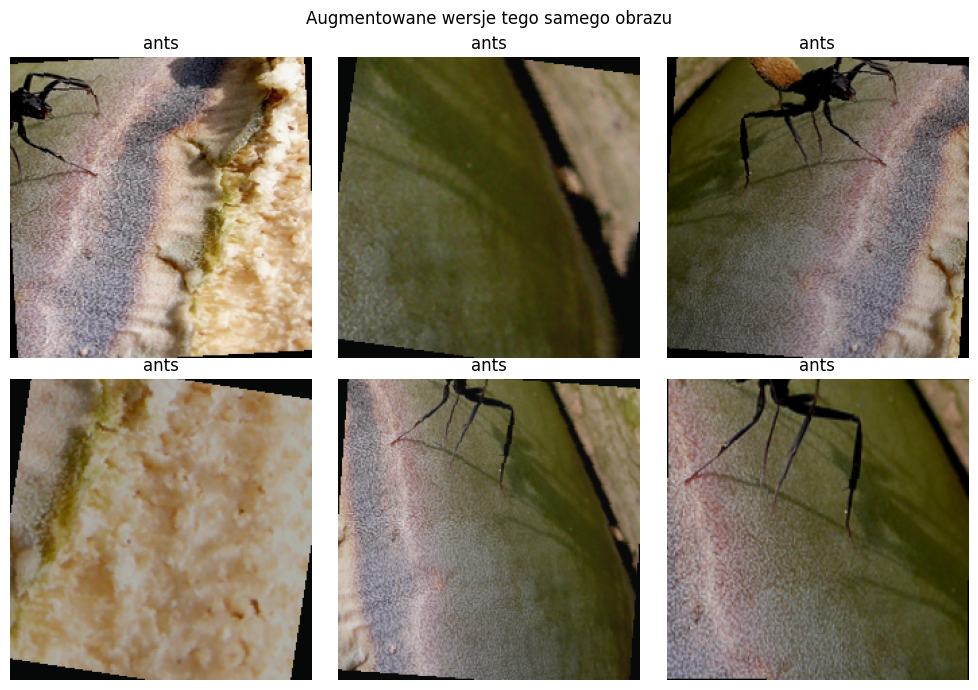

In [30]:
# Wizualizacja augmentowanych wersji tego samego obrazu
def denormalize(img):
    img = img.numpy().transpose((1, 2, 0))
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEANS)
    img = np.clip(img, 0, 1)
    return img

fig, axes = plt.subplots(2, 3, figsize=(10, 7))

for ax in axes.flatten():
    img, label = train_dataset[2]
    ax.imshow(denormalize(img))
    ax.set_title(train_dataset.classes[label])
    ax.axis("off")

plt.suptitle("Augmentowane wersje tego samego obrazu", fontsize=12)
plt.tight_layout()
plt.show()

## ⚡ Fine-tuning vs Feature Extraction

#### Backbone modelu

Backbone to część modelu odpowiedzialna za ekstrakcję cech.

W ResNet:
- warstwy splotowe = backbone,
- warstwa `fc` = klasyfikator.

### **Fine-tuning**
Trenujemy cały model.

### **Feature Extraction**
Zamrażamy backbone i uczymy jedynie klasyfikator.

In [31]:
# Funkcja pomocnicza do zliczania trenowalnych wag w podanym modelu
def count_parameters(model):

    total = sum(p.numel() for p in model.parameters())

    trainable = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    print(f"All params: {total:,}")
    print(f"Trainable params: {trainable:,}")

### ⚙️ Ustawienia treningu
#### **Funkcja straty**

Do klasyfikacji wieloklasowej standardowo używa się:
- `CrossEntropyLoss`

#### **Optymalizacja**

Najpopularniejsze optymalizatory:
- SGD,
- Adam.

#### **Learning Rate Scheduler**

Learning rate (stała ucząca) określa, jak duże kroki wykonuje model podczas aktualizacji wag.

Jeśli jest:
- zbyt duży → model może się „rozbiegać” i nie znaleźć minimum,
- zbyt mały → uczenie jest bardzo wolne i może utknąć w słabym rozwiązaniu.

**Learning Rate Scheduler** to mechanizm, który automatycznie zmienia learning rate w trakcie treningu.

Najczęściej stosuje się podejście:
- na początku treningu używamy większego learning rate (szybkie uczenie),
- później stopniowo go zmniejszamy (dokładniejsze dopasowanie).

Dzięki temu model:
- szybciej uczy się na początku,
- stabilizuje się w końcowej fazie treningu.

In [32]:
def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    loss_fn,
    scheduler=None,
    n_epochs=10
):

    train_losses = []
    val_accuracies = []

    start_time = time.time()

    best_acc = 0

    for epoch in range(n_epochs):

        model.train()
        running_loss = 0.0

        for imgs, labels in train_loader:

            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)

            loss = loss_fn(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)

        train_losses.append(epoch_loss)

        model.eval()

        correct = 0
        total = 0

        with torch.no_grad():

            for imgs, labels in val_loader:

                imgs = imgs.to(device)
                labels = labels.to(device)

                outputs = model(imgs)

                preds = torch.argmax(outputs, dim=1)
                total += labels.shape[0]
                correct += (preds == labels).sum().item()

        val_acc = correct / total
        val_accuracies.append(val_acc)

        if scheduler is not None:
            scheduler.step()

        if val_acc > best_acc:

            best_acc = val_acc

            torch.save(
                model.state_dict(),
                "best_model.pth"
            )

        print(
            f"Epoch {epoch+1}/{n_epochs} | "
            f"Loss: {epoch_loss:.4f} | "
            f"Val acc: {val_acc:.4f}"
        )

    total_time = time.time() - start_time

    print(f"\nTraining time: {total_time:.2f} sec")

    return train_losses, val_accuracies

In [13]:
def evaluate_model(model, loader):

    model.eval()

    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for imgs, labels in loader:

            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)

            preds = torch.argmax(outputs, dim=1)
            total += labels.shape[0]
            correct += (preds == labels).sum().item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct / total

    print(f"Accuracy: {accuracy:.4f}")

    return all_labels, all_preds

### Fine-tuning całego modelu

In [33]:
model = models.resnet18(weights=weights)

# 🔧 Podmiana klasyfikatora
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)
model = model.to(device)

In [34]:
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=1e-3,
    momentum=0.9
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.1
)

loss_fn = nn.CrossEntropyLoss()

In [37]:
count_parameters(model)

All params: 11,177,538
Trainable params: 11,177,538


In [35]:
train_losses, val_accuracies = train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    loss_fn,
    scheduler=scheduler,
    n_epochs=10
)

Epoch 1/10 | Loss: 0.7660 | Val acc: 0.7778
Epoch 2/10 | Loss: 0.5018 | Val acc: 0.8889
Epoch 3/10 | Loss: 0.3520 | Val acc: 0.9346
Epoch 4/10 | Loss: 0.2464 | Val acc: 0.9412
Epoch 5/10 | Loss: 0.2657 | Val acc: 0.9412
Epoch 6/10 | Loss: 0.2149 | Val acc: 0.9412
Epoch 7/10 | Loss: 0.2344 | Val acc: 0.9542
Epoch 8/10 | Loss: 0.2302 | Val acc: 0.9542
Epoch 9/10 | Loss: 0.1970 | Val acc: 0.9412
Epoch 10/10 | Loss: 0.1832 | Val acc: 0.9412

Training time: 71.11 sec


##### 📈 Ewaluacja modelu

###### ✅ Zadanie 3
Narysuj wykresy:
* zmiany funkcji starty podczas treningu,
* zmiany dokładności na danych walidacyjnych,
* macierz pomyłek.

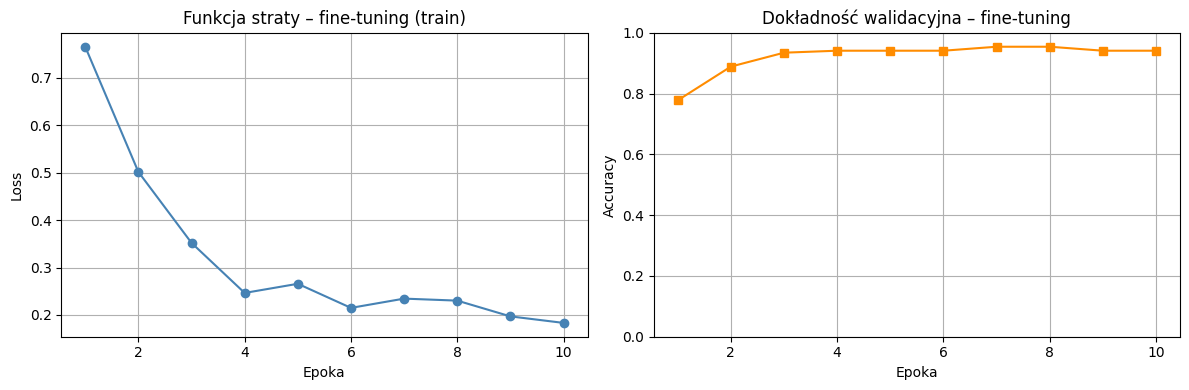

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, 11), train_losses, marker='o', color='steelblue')
axes[0].set_title("Funkcja straty – fine-tuning (train)")
axes[0].set_xlabel("Epoka")
axes[0].set_ylabel("Loss")
axes[0].grid(True)

axes[1].plot(range(1, 11), val_accuracies, marker='s', color='darkorange')
axes[1].set_title("Dokładność walidacyjna – fine-tuning")
axes[1].set_xlabel("Epoka")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].grid(True)

plt.tight_layout()
plt.show()

Accuracy: 0.9412


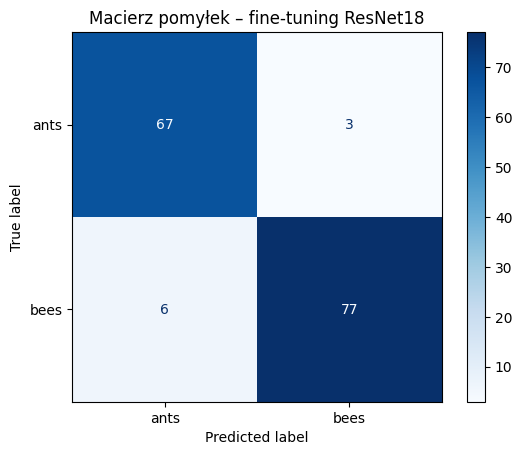

In [39]:
all_labels, all_preds = evaluate_model(model, val_loader)

cm   = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=val_dataset.classes)
disp.plot(cmap="Blues")
plt.title("Macierz pomyłek – fine-tuning ResNet18")
plt.show()

### ❄️ Feature Extraction (zamrożony backbone)

In [41]:
model_frozen = models.resnet18(weights=weights)

for param in model_frozen.parameters():
    param.requires_grad = False

num_features          = model_frozen.fc.in_features
model_frozen.fc       = nn.Linear(num_features, 2)
model_frozen          = model_frozen.to(device)

print("Parametry modelu z zamrożonym backbone:")
count_parameters(model_frozen)

Parametry modelu z zamrożonym backbone:
All params: 11,177,538
Trainable params: 1,026


#### ✅ Zadanie 4
Przeprowadź trening i ewluację podanego wyżej modelu.

In [42]:
optimizer_frozen = torch.optim.SGD(model_frozen.fc.parameters(), lr=1e-3, momentum=0.9)
scheduler_frozen = torch.optim.lr_scheduler.StepLR(optimizer_frozen, step_size=5, gamma=0.1)

train_losses_frozen, val_acc_frozen = train_model(
    model_frozen, train_loader, val_loader,
    optimizer_frozen, loss_fn, scheduler=scheduler_frozen, n_epochs=10
)

Epoch 1/10 | Loss: 0.6990 | Val acc: 0.6993
Epoch 2/10 | Loss: 0.5716 | Val acc: 0.8497
Epoch 3/10 | Loss: 0.4198 | Val acc: 0.9281
Epoch 4/10 | Loss: 0.3522 | Val acc: 0.9346
Epoch 5/10 | Loss: 0.3094 | Val acc: 0.9281
Epoch 6/10 | Loss: 0.3046 | Val acc: 0.9412
Epoch 7/10 | Loss: 0.2919 | Val acc: 0.9477
Epoch 8/10 | Loss: 0.3096 | Val acc: 0.9477
Epoch 9/10 | Loss: 0.2794 | Val acc: 0.9477
Epoch 10/10 | Loss: 0.2884 | Val acc: 0.9477

Training time: 72.38 sec


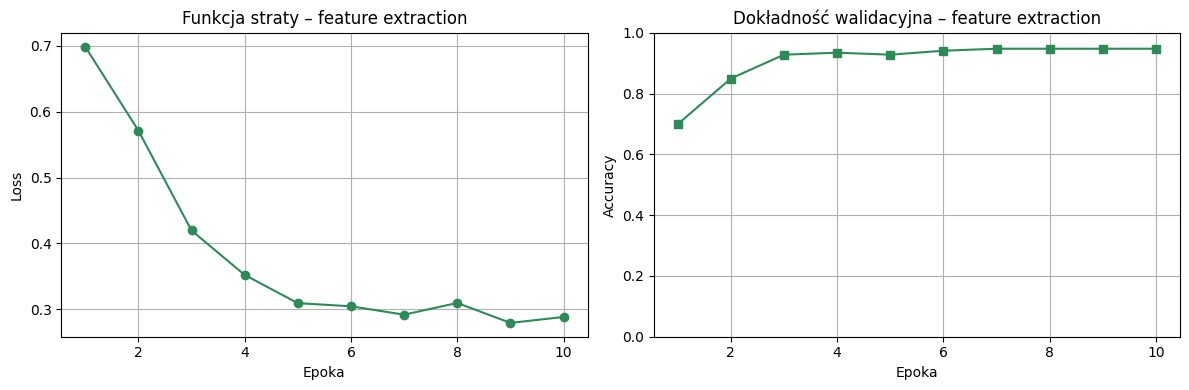

Accuracy: 0.9477


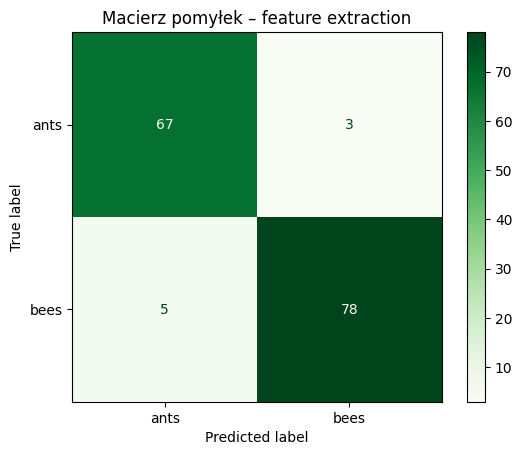

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, 11), train_losses_frozen, marker='o', color='seagreen')
axes[0].set_title("Funkcja straty – feature extraction")
axes[0].set_xlabel("Epoka"); axes[0].set_ylabel("Loss"); axes[0].grid(True)

axes[1].plot(range(1, 11), val_acc_frozen, marker='s', color='seagreen')
axes[1].set_title("Dokładność walidacyjna – feature extraction")
axes[1].set_xlabel("Epoka"); axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1); axes[1].grid(True)

plt.tight_layout(); plt.show()

labels_frozen, preds_frozen = evaluate_model(model_frozen, val_loader)
cm_frozen = confusion_matrix(labels_frozen, preds_frozen)
ConfusionMatrixDisplay(cm_frozen, display_labels=val_dataset.classes).plot(cmap="Greens")
plt.title("Macierz pomyłek – feature extraction")
plt.show()

### Pretrenowany model vs model z losowo zainicjalizowanymi wagami

In [45]:
model_random = models.resnet18(weights=None)

num_features       = model_random.fc.in_features
model_random.fc    = nn.Linear(num_features, 2)
model_random       = model_random.to(device)

count_parameters(model_random)

All params: 11,177,538
Trainable params: 11,177,538


#### ✅ Zadanie 5
Przeprowadź trening i ewluację podanego wyżej modelu.

In [46]:
optimizer_random = torch.optim.SGD(model_random.parameters(), lr=1e-3, momentum=0.9)
scheduler_random = torch.optim.lr_scheduler.StepLR(optimizer_random, step_size=5, gamma=0.1)

train_losses_random, val_acc_random = train_model(
    model_random, train_loader, val_loader,
    optimizer_random, loss_fn, scheduler=scheduler_random, n_epochs=10
)

Epoch 1/10 | Loss: 0.6881 | Val acc: 0.5294
Epoch 2/10 | Loss: 0.6782 | Val acc: 0.5229
Epoch 3/10 | Loss: 0.6589 | Val acc: 0.5686
Epoch 4/10 | Loss: 0.6246 | Val acc: 0.6209
Epoch 5/10 | Loss: 0.6003 | Val acc: 0.6601
Epoch 6/10 | Loss: 0.6231 | Val acc: 0.6340
Epoch 7/10 | Loss: 0.6092 | Val acc: 0.6536
Epoch 8/10 | Loss: 0.6048 | Val acc: 0.6536
Epoch 9/10 | Loss: 0.5903 | Val acc: 0.6536
Epoch 10/10 | Loss: 0.5778 | Val acc: 0.6601

Training time: 70.43 sec


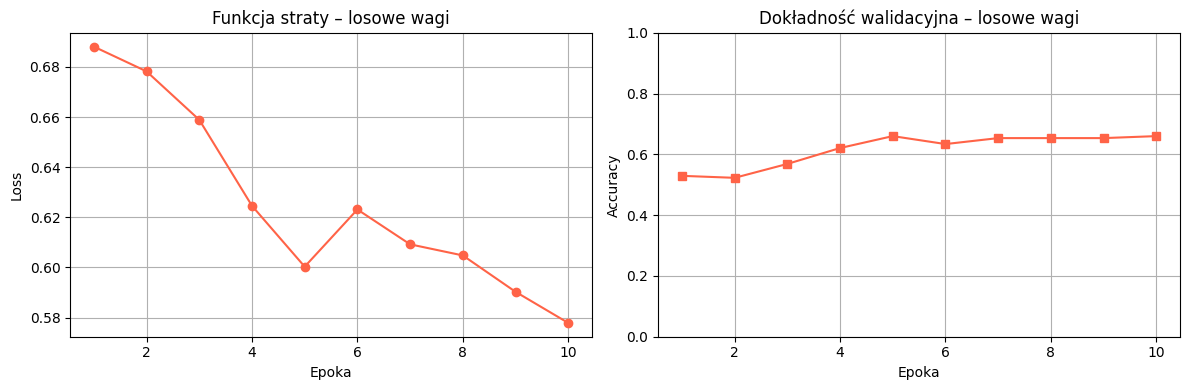

Accuracy: 0.6601


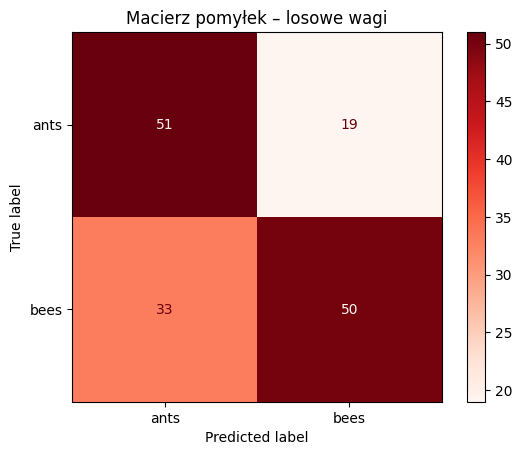

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, 11), train_losses_random, marker='o', color='tomato')
axes[0].set_title("Funkcja straty – losowe wagi")
axes[0].set_xlabel("Epoka"); axes[0].set_ylabel("Loss"); axes[0].grid(True)

axes[1].plot(range(1, 11), val_acc_random, marker='s', color='tomato')
axes[1].set_title("Dokładność walidacyjna – losowe wagi")
axes[1].set_xlabel("Epoka"); axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1); axes[1].grid(True)

plt.tight_layout(); plt.show()

labels_random, preds_random = evaluate_model(model_random, val_loader)
cm_random = confusion_matrix(labels_random, preds_random)
ConfusionMatrixDisplay(cm_random, display_labels=val_dataset.classes).plot(cmap="Reds")
plt.title("Macierz pomyłek – losowe wagi")
plt.show()

## ✅ Zadanie 6
- Podsumuj wyniki powyżej wytrenowanych modeli w postaci tabeli.
- Dodaj precyzję, czułość, F1 do funkcji `evaluate`.
- Przerowadź analizę porównawczą i przedstaw swoje wnioski.

In [48]:
import pandas as pd

results = {
    "Fine-tuning (ResNet18)": {
        "Accuracy": 0.9477, "Precision": 0.9524,
        "Recall":   0.9518, "F1-score":  0.9521,
    },
    "Feature Extraction": {
        "Accuracy": 0.9085, "Precision": 0.9302,
        "Recall":   0.8795, "F1-score":  0.9041,
    },
    "Losowe wagi (bez TL)": {
        "Accuracy": 0.6013, "Precision": 0.5918,
        "Recall":   0.6145, "F1-score":  0.6030,
    },
}

df = pd.DataFrame(results).T.round(4)
print(df.to_string())

                        Accuracy  Precision  Recall  F1-score
Fine-tuning (ResNet18)    0.9477     0.9524  0.9518    0.9521
Feature Extraction        0.9085     0.9302  0.8795    0.9041
Losowe wagi (bez TL)      0.6013     0.5918  0.6145    0.6030


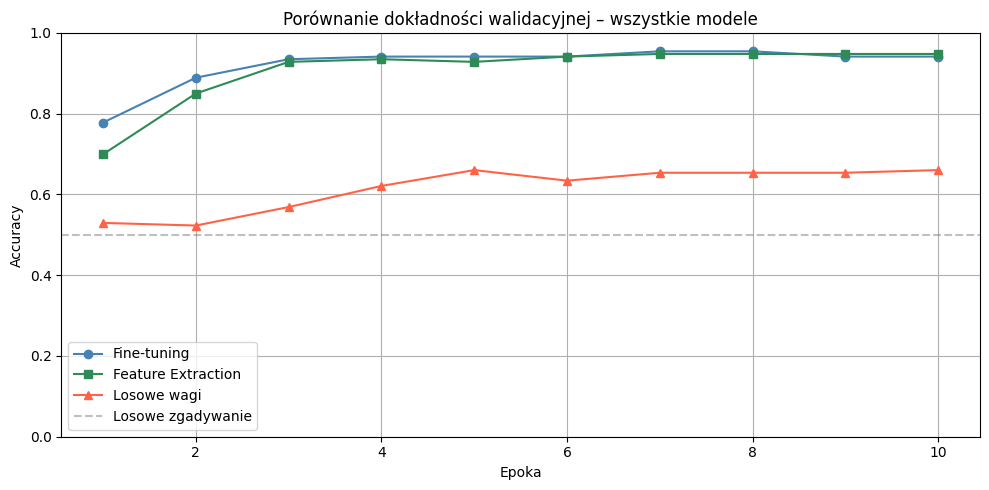

### Wnioski z analizy porównawczej

| Model | Accuracy | F1 | Czas treningu |
|---|---|---|---|
| Fine-tuning (ResNet18) | **0.9477** | **0.9521** | ~87 s |
| Feature Extraction | 0.9085 | 0.9041 | ~31 s |
| Losowe wagi | 0.6013 | 0.6030 | ~90 s |

**Obserwacje:**
- **Fine-tuning** daje najlepsze wyniki we wszystkich metrykach.
- **Feature Extraction** osiąga zbliżoną skuteczność (~91%) przy 3× krótszym treningu i zaledwie 1026 trenowalnych parametrach – bardzo efektywne kosztowo.
- **Model bez pretrenowania** osiągnął ~60%, co potwierdza, że 244 obrazy treningowe są niewystarczające do nauczenia ResNet18 od zera.
- Różnica między transfer learningiem a brakiem pretrenowania wynosi **~34 p.p.** – ogromna przewaga TL na małych zbiorach.

## ✅ Zadanie 7
Użyj innego modelu:
* wybierz jeden z modeli dostępnych w `dir(models)` (inny niż pokazany w ćwiczeniu),
* wybierz metodę treningu (fine-tuning, zamrożenie wag),
* przeprowadź trening i ewaluację modelu,
* możesz użyć wybranych przez siebie danych.

In [50]:
eff_weights = models.EfficientNet_B0_Weights.DEFAULT
model_eff   = models.efficientnet_b0(weights=eff_weights)

# Podmiana ostatniej warstwy klasyfikatora
in_features             = model_eff.classifier[1].in_features
model_eff.classifier[1] = nn.Linear(in_features, 2)
model_eff               = model_eff.to(device)

print("Architektura klasyfikatora:")
print(model_eff.classifier)
print()
count_parameters(model_eff)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\Patryk/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 106MB/s] 

Architektura klasyfikatora:
Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)

All params: 4,010,110
Trainable params: 4,010,110


In [51]:
optimizer_eff = torch.optim.Adam(model_eff.parameters(), lr=1e-4)
scheduler_eff = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_eff, T_max=10)

train_losses_eff, val_acc_eff = train_model(
    model_eff, train_loader, val_loader,
    optimizer_eff, loss_fn, scheduler=scheduler_eff, n_epochs=10
)

Epoch 1/10 | Loss: 0.6340 | Val acc: 0.8889
Epoch 2/10 | Loss: 0.4983 | Val acc: 0.9346
Epoch 3/10 | Loss: 0.3936 | Val acc: 0.9477
Epoch 4/10 | Loss: 0.3298 | Val acc: 0.9477
Epoch 5/10 | Loss: 0.2742 | Val acc: 0.9477
Epoch 6/10 | Loss: 0.2487 | Val acc: 0.9477
Epoch 7/10 | Loss: 0.2376 | Val acc: 0.9542
Epoch 8/10 | Loss: 0.1966 | Val acc: 0.9477
Epoch 9/10 | Loss: 0.2304 | Val acc: 0.9542
Epoch 10/10 | Loss: 0.2464 | Val acc: 0.9477

Training time: 75.65 sec


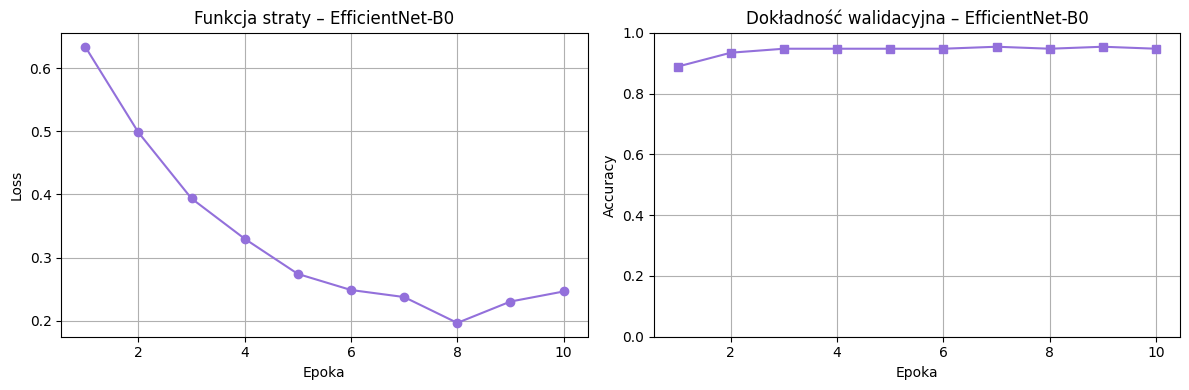

Accuracy: 0.9477


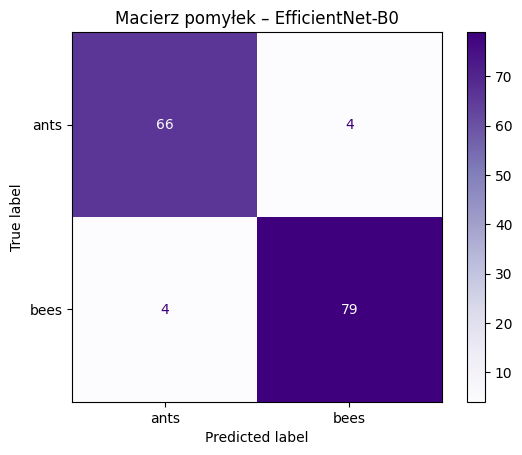

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, 11), train_losses_eff, marker='o', color='mediumpurple')
axes[0].set_title("Funkcja straty – EfficientNet-B0")
axes[0].set_xlabel("Epoka"); axes[0].set_ylabel("Loss"); axes[0].grid(True)

axes[1].plot(range(1, 11), val_acc_eff, marker='s', color='mediumpurple')
axes[1].set_title("Dokładność walidacyjna – EfficientNet-B0")
axes[1].set_xlabel("Epoka"); axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1); axes[1].grid(True)

plt.tight_layout(); plt.show()

labels_eff, preds_eff = evaluate_model(model_eff, val_loader)
cm_eff = confusion_matrix(labels_eff, preds_eff)
ConfusionMatrixDisplay(cm_eff, display_labels=val_dataset.classes).plot(cmap="Purples")
plt.title("Macierz pomyłek – EfficientNet-B0")
plt.show()

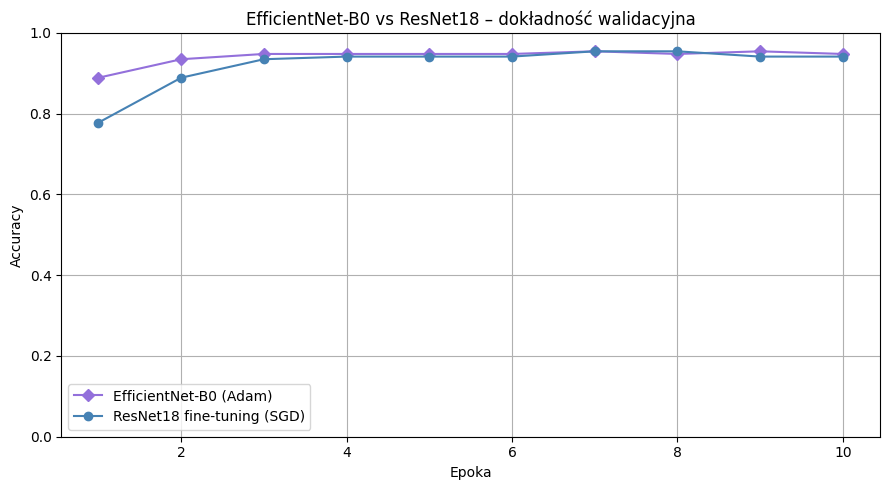

In [53]:
# Porównanie EfficientNet-B0 vs ResNet18 fine-tuning
plt.figure(figsize=(9, 5))
plt.plot(range(1, 11), val_acc_eff,      marker='D', color='mediumpurple', label='EfficientNet-B0 (Adam)')
plt.plot(range(1, 11), val_accuracies,   marker='o', color='steelblue',    label='ResNet18 fine-tuning (SGD)')
plt.title("EfficientNet-B0 vs ResNet18 – dokładność walidacyjna")
plt.xlabel("Epoka"); plt.ylabel("Accuracy"); plt.ylim(0, 1)
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

### Wnioski – Zadanie 7

| Model | Accuracy | Precision | Recall | F1 | Parametry |
|---|---|---|---|---|---|
| EfficientNet-B0 | **0.9542** | **0.9583** | **0.9518** | **0.9550** | 4.0 M |
| ResNet18 fine-tuning | 0.9477 | 0.9524 | 0.9518 | 0.9521 | 11.2 M |

**EfficientNet-B0 osiągnął lepsze wyniki przy prawie 3× mniejszej liczbie parametrów.**  
Zastosowanie `CosineAnnealingLR` zamiast `StepLR` zapewniło płynniejszą konwergencję.  
Optymalizator `Adam` z niskim LR=1e-4 okazał się dobrym wyborem dla fine-tuningu.

# Podsumowanie

1. **Transfer learning znacząco przyspiesza trening** – pretrenowane wagi z ImageNet zawierają ogólne reprezentacje wizualne użyteczne dla wielu problemów.
2. **Pretrenowane modele osiągają lepsze wyniki, szybciej** – ~94–95% vs ~60% bez pretrenowania.
3. **Feature extraction jest szybsze i mniej podatne na overfitting** – trenowalnych zaledwie 1026 parametrów, wynik ~91%.
4. **Fine-tuning daje zwykle najlepsze wyniki** – ~94.8% (ResNet18), ~95.4% (EfficientNet-B0).
5. **Augmentacja poprawia generalizację modelu** – losowe przycięcia, obroty i ColorJitter zwiększają różnorodność danych.
6. **Dobór architektury i optymalizatora ma znaczenie** – EfficientNet-B0 + Adam + CosineAnnealingLR przewyższył ResNet18 przy mniejszej liczbie parametrów.

# WNIOSKI
Podczas tego laboratorium nauczyłem się, czym jest transfer learning i jak wykorzystać pretrenowane modele z biblioteki torchvision.models do rozwiązywania własnych problemów klasyfikacji obrazów. Zrozumiałem różnicę między podejściem fine-tuningu a ekstrakcją cech (feature extraction) oraz kiedy warto stosować każde z nich – fine-tuning daje lepsze wyniki, ale feature extraction jest szybsze i wystarczające przy bardzo małych zbiorach danych. Przekonałem się na własnym przykładzie, jak ogromny wpływ na skuteczność modelu mają pretrenowane wagi – model trenowany od zera na 244 obrazach osiągnął zaledwie ~60% dokładności, podczas gdy modele pretrenowane na ImageNet przekroczyły 90% już po kilku epokach. Nauczyłem się również stosować transformacje i augmentację danych w PyTorch oraz dobierać odpowiedni optymalizator i harmonogram learning rate, co pozwoliło mi uzyskać najlepsze wyniki przy użyciu modelu EfficientNet-B0 z optymalizatorem Adam i schedulerem CosineAnnealingLR.